In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

print('Seaborn version:', sns.__version__)
sns.set_style('whitegrid')

Seaborn version: 0.13.2


In [2]:
# Load CSV
df = pd.read_csv('bestsellers with categories.csv')

# Show first 5 rows to confirm it loaded correctly
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [3]:
# Rename columns for consistency
df.rename(columns={"User Rating": "User_Rating"}, inplace=True)

# Fix author name inconsistencies
df.loc[df.Author == 'J. K. Rowling', 'Author'] = 'J.K. Rowling'

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Check duplicates and remove
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

# Feature: length of book name (excluding spaces)
df['name_len'] = df['Name'].apply(lambda x: len(x) - x.count(" "))

# Feature: punctuation percentage in book name
punctuations = string.punctuation
print('List of punctuations:', punctuations)

def count_punc(text):
    """Counts percentage of punctuations in text"""
    count = sum(1 for char in text if char in punctuations)
    return round(count / (len(text) - text.count(" ")) * 100, 3)

df['punc%'] = df['Name'].apply(lambda x: count_punc(x))

# Check first 5 rows after preparation
df.head()

Missing values:
 Name           0
Author         0
User_Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64
Duplicate rows before: 0
Duplicate rows after: 0
List of punctuations: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


,Name,Author,User_Rating,Reviews,Price,Year,Genre,name_len,punc%
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction,26,3.846
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction,15,20.000
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction,32,3.125
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction,20,10.000
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction,59,10.169


In [5]:
df_filtered = df.copy()

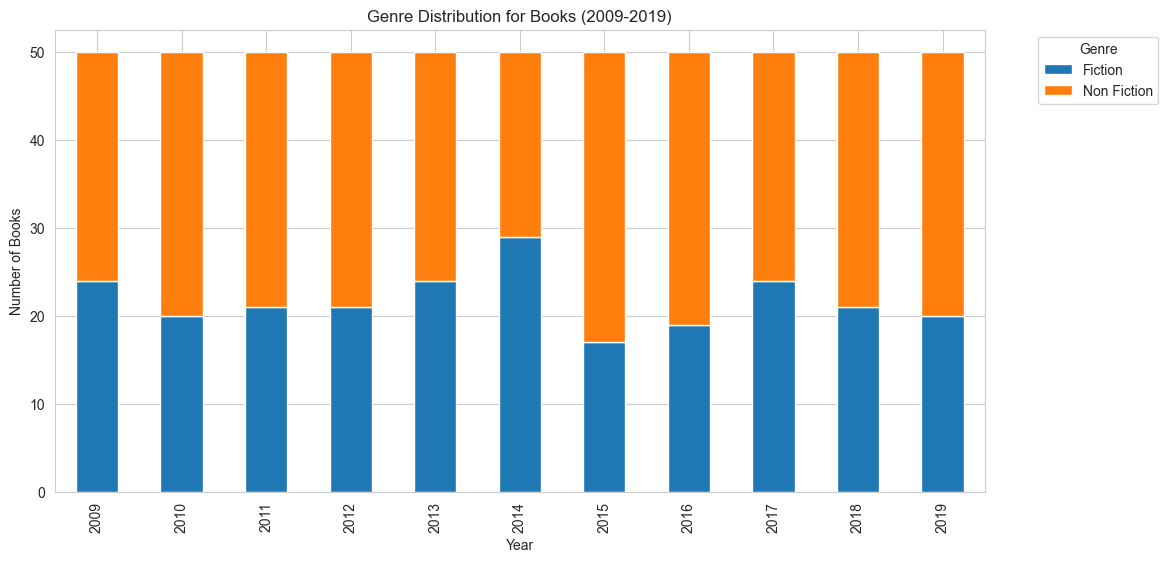

In [6]:
# Prepare a pivot table: count of books per Genre per Year
genre_year = df_filtered.groupby(['Year','Genre']).size().unstack(fill_value=0)

# Plot stacked bar chart
genre_year.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Genre Distribution for Books (2009-2019)')
plt.xlabel('Year')
plt.ylabel('Number of Books')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

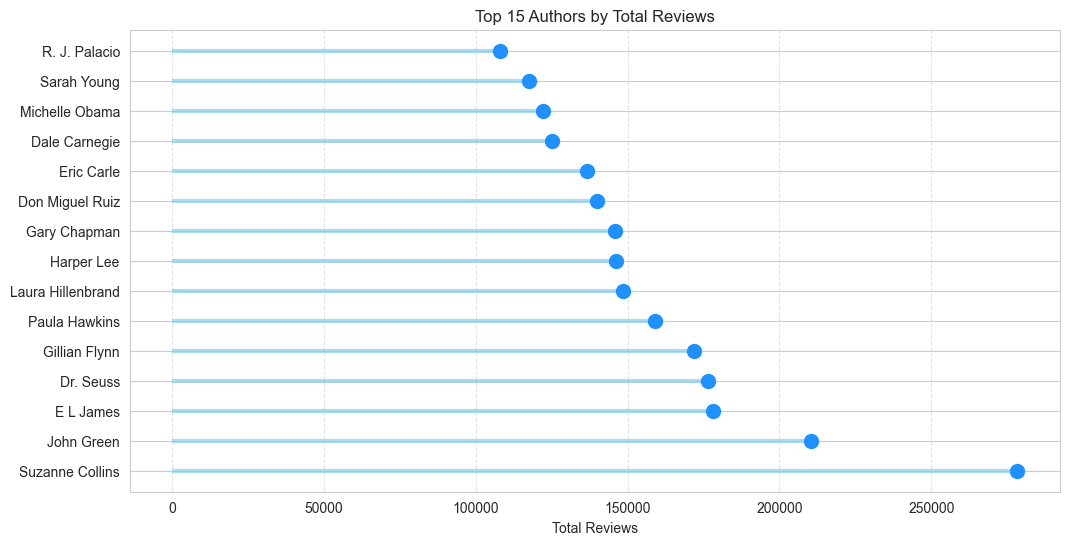

In [7]:
# Top 15 authors by total reviews
top_authors = df.groupby('Author')['Reviews'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

# Horizontal lollipop chart
plt.hlines(y=top_authors.index, xmin=0, xmax=top_authors.values, color='skyblue', alpha=0.7, linewidth=3)
plt.plot(top_authors.values, top_authors.index, "o", color='dodgerblue', markersize=10)

plt.xlabel('Total Reviews')
plt.title('Top 15 Authors by Total Reviews')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

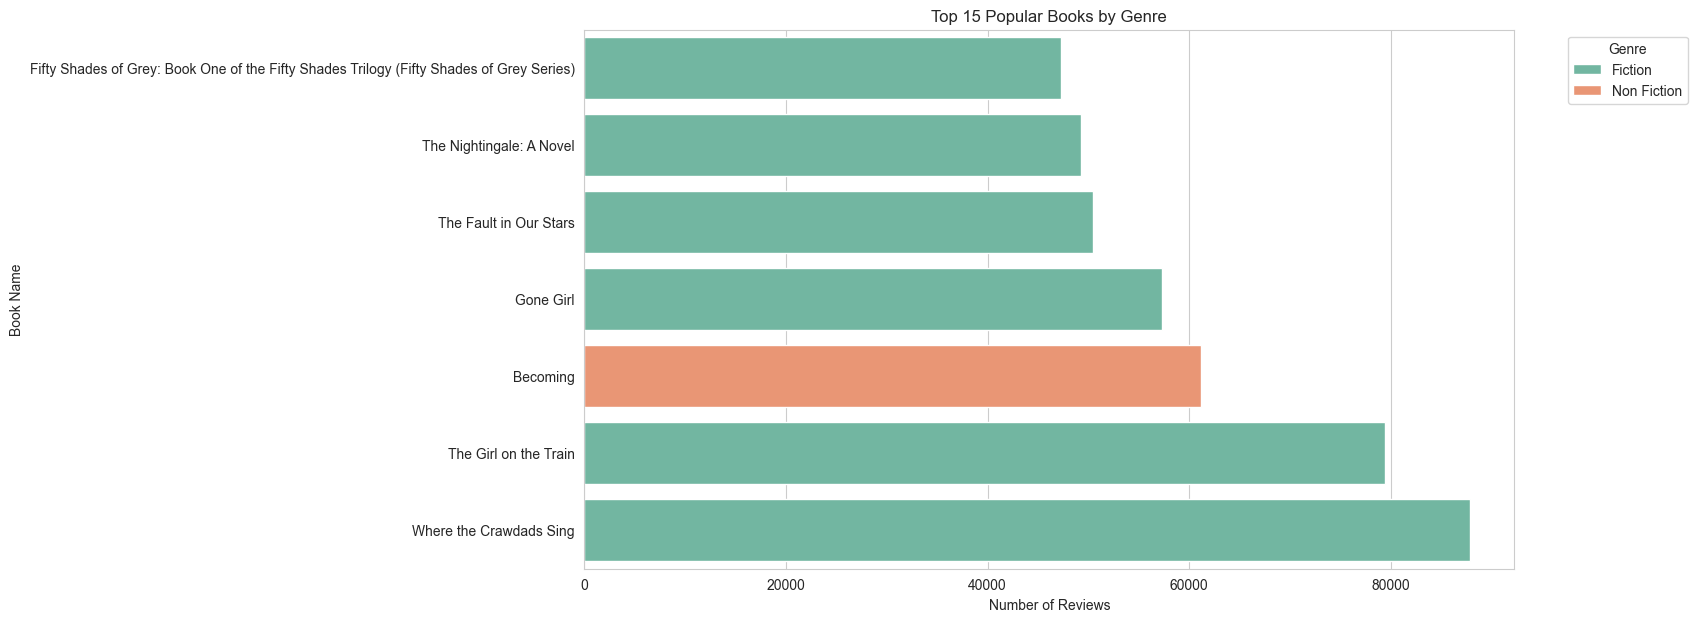

In [8]:
# Top 15 most reviewed books
top_books = df.sort_values(by='Reviews', ascending=False).head(15)

plt.figure(figsize=(12,7))

# Horizontal bar chart
sns.barplot(
    x='Reviews', 
    y='Name', 
    data=top_books, 
    hue='Genre', 
    dodge=False,        # keeps bars single color per book
    palette='Set2'
)

plt.xlabel('Number of Reviews')
plt.ylabel('Book Name')
plt.title('Top 15 Popular Books by Genre')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().invert_yaxis()  # highest reviewed book on top
plt.show()

C:\Users\hariv\AppData\Local\Temp\ipykernel_18872\1304168424.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  price_genre = df.pivot_table(index='Price_Range', columns='Genre', values='Reviews', aggfunc='sum', fill_value=0)


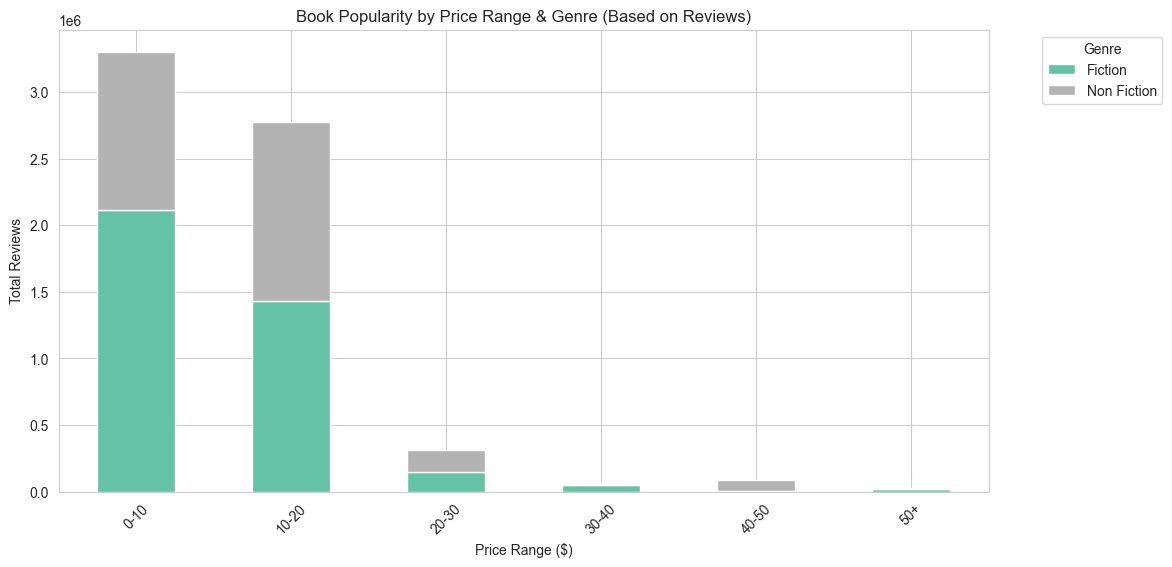

In [9]:
# Create price categories
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50+']
df['Price_Range'] = pd.cut(df['Price'], bins=bins, labels=labels, include_lowest=True)

# Pivot table: total reviews per genre per price range
price_genre = df.pivot_table(index='Price_Range', columns='Genre', values='Reviews', aggfunc='sum', fill_value=0)

# Stacked bar chart
price_genre.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.title('Book Popularity by Price Range & Genre (Based on Reviews)')
plt.xlabel('Price Range ($)')
plt.ylabel('Total Reviews')
plt.xticks(rotation=45)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()